In [ ]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [16]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Assuming the uploaded file is a CSV
  try:
    df_myim3rev = pd.read_csv(io.BytesIO(uploaded[fn]))
    print("Successfully loaded CSV into df_jknrev")
  except pd.errors.ParserError:
      print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
      df_myim3rev= pd.DataFrame() # Create an empty DataFrame if parsing fails
  except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df_myim3rev = pd.DataFrame()


Saving data_hasil_crawling_myim3.csv to data_hasil_crawling_myim3 (1).csv
User uploaded file "data_hasil_crawling_myim3 (1).csv" with length 2141046 bytes
Successfully loaded CSV into df_jknrev


In [17]:
df_myim3rev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4bb40d9f-6391-41f8-81cb-7198ec17307e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,jaringan nya suka nge lag parah!!!,1,0,NaN,2026-04-17 04:22:23,Mohon maaf Ibu Riri. Silahkan lakukan restart ...,2026-04-17 04:40:00,NaN
1,15925501-4cba-4118-a4fd-da9d49dd6ce2,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,INTERNET NYA JELEK NGELAG BGT. PDHL KUOTA SAYA...,1,0,82.13.1,2026-04-17 04:00:42,"Hai Bapak Rafan, mohon maaf atas kendala yang ...",2026-04-17 04:41:34,82.13.1
2,4785018f-9f7b-434b-bdfd-83e398f6931f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"tolo perbaiki fitur pembatalan langganan, lang...",4,0,82.13.1,2026-04-16 23:41:21,NaN,NaN,82.13.1
3,5ae48566-9bc4-44f8-a3d8-a6b097c71863,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,eSim udah milih ama regis nomor sesuai yg diin...,1,0,NaN,2026-04-16 17:32:10,"Hai Bapak Bayu, mohon maaf sebelumnya. Untuk b...",2026-04-17 03:30:45,NaN
4,e23b92ab-fe60-4991-8211-216e458df26f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Provider apasih ini?, sumpah udah mahal, ngela...",1,0,NaN,2026-04-16 16:54:53,"Hai Pelanggan IM3, mohon maaf atas kendalanya....",2026-04-17 03:19:30,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4495,44f76cd2-e6a1-40d2-866e-9e4c1c070c5c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi tidak bisa jalan,1,0,82.5.0,2024-11-19 22:14:40,"Hai Kak Dhimas, maaf sebelumnya. Pastikan suda...",2024-11-20 05:30:05,82.5.0
4496,0e136fea-9ba4-41e7-94b9-b7a655103cdb,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Paket bundle sama vidio link aktivasi nya ga d...,1,0,NaN,2024-11-19 19:12:18,"Hai Kak Ribby , maaf sebelumnya. Untuk bisa me...",2024-11-20 04:54:06,NaN
4497,c0ff9ef7-8b64-4ef8-866e-b9f37999efd9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah berkali-kali login tetap gabisa masuk. J...,1,0,NaN,2024-11-19 17:46:00,"Hai Kak Nur, maaf sebelumnya. Untuk bisa memba...",2024-11-20 05:08:47,NaN
4498,cbd42c93-60d4-47f6-8cbd-22c17916188a,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,tolong permudah utang kouta,2,0,82.5.0,2024-11-19 17:31:43,"Hai Kak Arif , maaf sebelumnya. Untuk bisa mem...",2024-11-20 05:10:39,82.5.0


In [18]:
df_myim3rev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              4500 non-null   object
 1   userName              4500 non-null   object
 2   userImage             4500 non-null   object
 3   content               4500 non-null   object
 4   score                 4500 non-null   int64 
 5   thumbsUpCount         4500 non-null   int64 
 6   reviewCreatedVersion  3776 non-null   object
 7   at                    4500 non-null   object
 8   replyContent          3112 non-null   object
 9   repliedAt             3112 non-null   object
 10  appVersion            3776 non-null   object
dtypes: int64(2), object(9)
memory usage: 386.8+ KB


In [19]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download Indonesian stopwords if not available
nltk.download('stopwords')
indonesian_stopwords = set(stopwords.words('indonesian'))

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_myim3rev[text_column].dropna().astype(str))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_myim3rev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,jaringan nya suka nge lag parah!!!,1,0,NaN,2026-04-17 04:22:23,Mohon maaf Ibu Riri. Silahkan lakukan restart ...,2026-04-17 04:40:00
1,INTERNET NYA JELEK NGELAG BGT. PDHL KUOTA SAYA...,1,0,82.13.1,2026-04-17 04:00:42,"Hai Bapak Rafan, mohon maaf atas kendala yang ...",2026-04-17 04:41:34
2,"tolo perbaiki fitur pembatalan langganan, lang...",4,0,82.13.1,2026-04-16 23:41:21,NaN,NaN
3,eSim udah milih ama regis nomor sesuai yg diin...,1,0,NaN,2026-04-16 17:32:10,"Hai Bapak Bayu, mohon maaf sebelumnya. Untuk b...",2026-04-17 03:30:45
4,"Provider apasih ini?, sumpah udah mahal, ngela...",1,0,NaN,2026-04-16 16:54:53,"Hai Pelanggan IM3, mohon maaf atas kendalanya....",2026-04-17 03:19:30
...,...,...,...,...,...,...,...
4495,Aplikasi tidak bisa jalan,1,0,82.5.0,2024-11-19 22:14:40,"Hai Kak Dhimas, maaf sebelumnya. Pastikan suda...",2024-11-20 05:30:05
4496,Paket bundle sama vidio link aktivasi nya ga d...,1,0,NaN,2024-11-19 19:12:18,"Hai Kak Ribby , maaf sebelumnya. Untuk bisa me...",2024-11-20 04:54:06
4497,Sudah berkali-kali login tetap gabisa masuk. J...,1,0,NaN,2024-11-19 17:46:00,"Hai Kak Nur, maaf sebelumnya. Untuk bisa memba...",2024-11-20 05:08:47
4498,tolong permudah utang kouta,2,0,82.5.0,2024-11-19 17:31:43,"Hai Kak Arif , maaf sebelumnya. Untuk bisa mem...",2024-11-20 05:10:39


##Stopwords Removal
Indonesian Stopwords

In [21]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
print(len(indonesian_stopwords))

758


In [ ]:
indonesian_stopwords

['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

,Word,Frequency
0,paket,655
1,ga,584
2,pulsa,528
3,pop,515
4,aplikasi,494
...,...,...
95,kualitas,72
96,update,72
97,that,71
98,chat,71


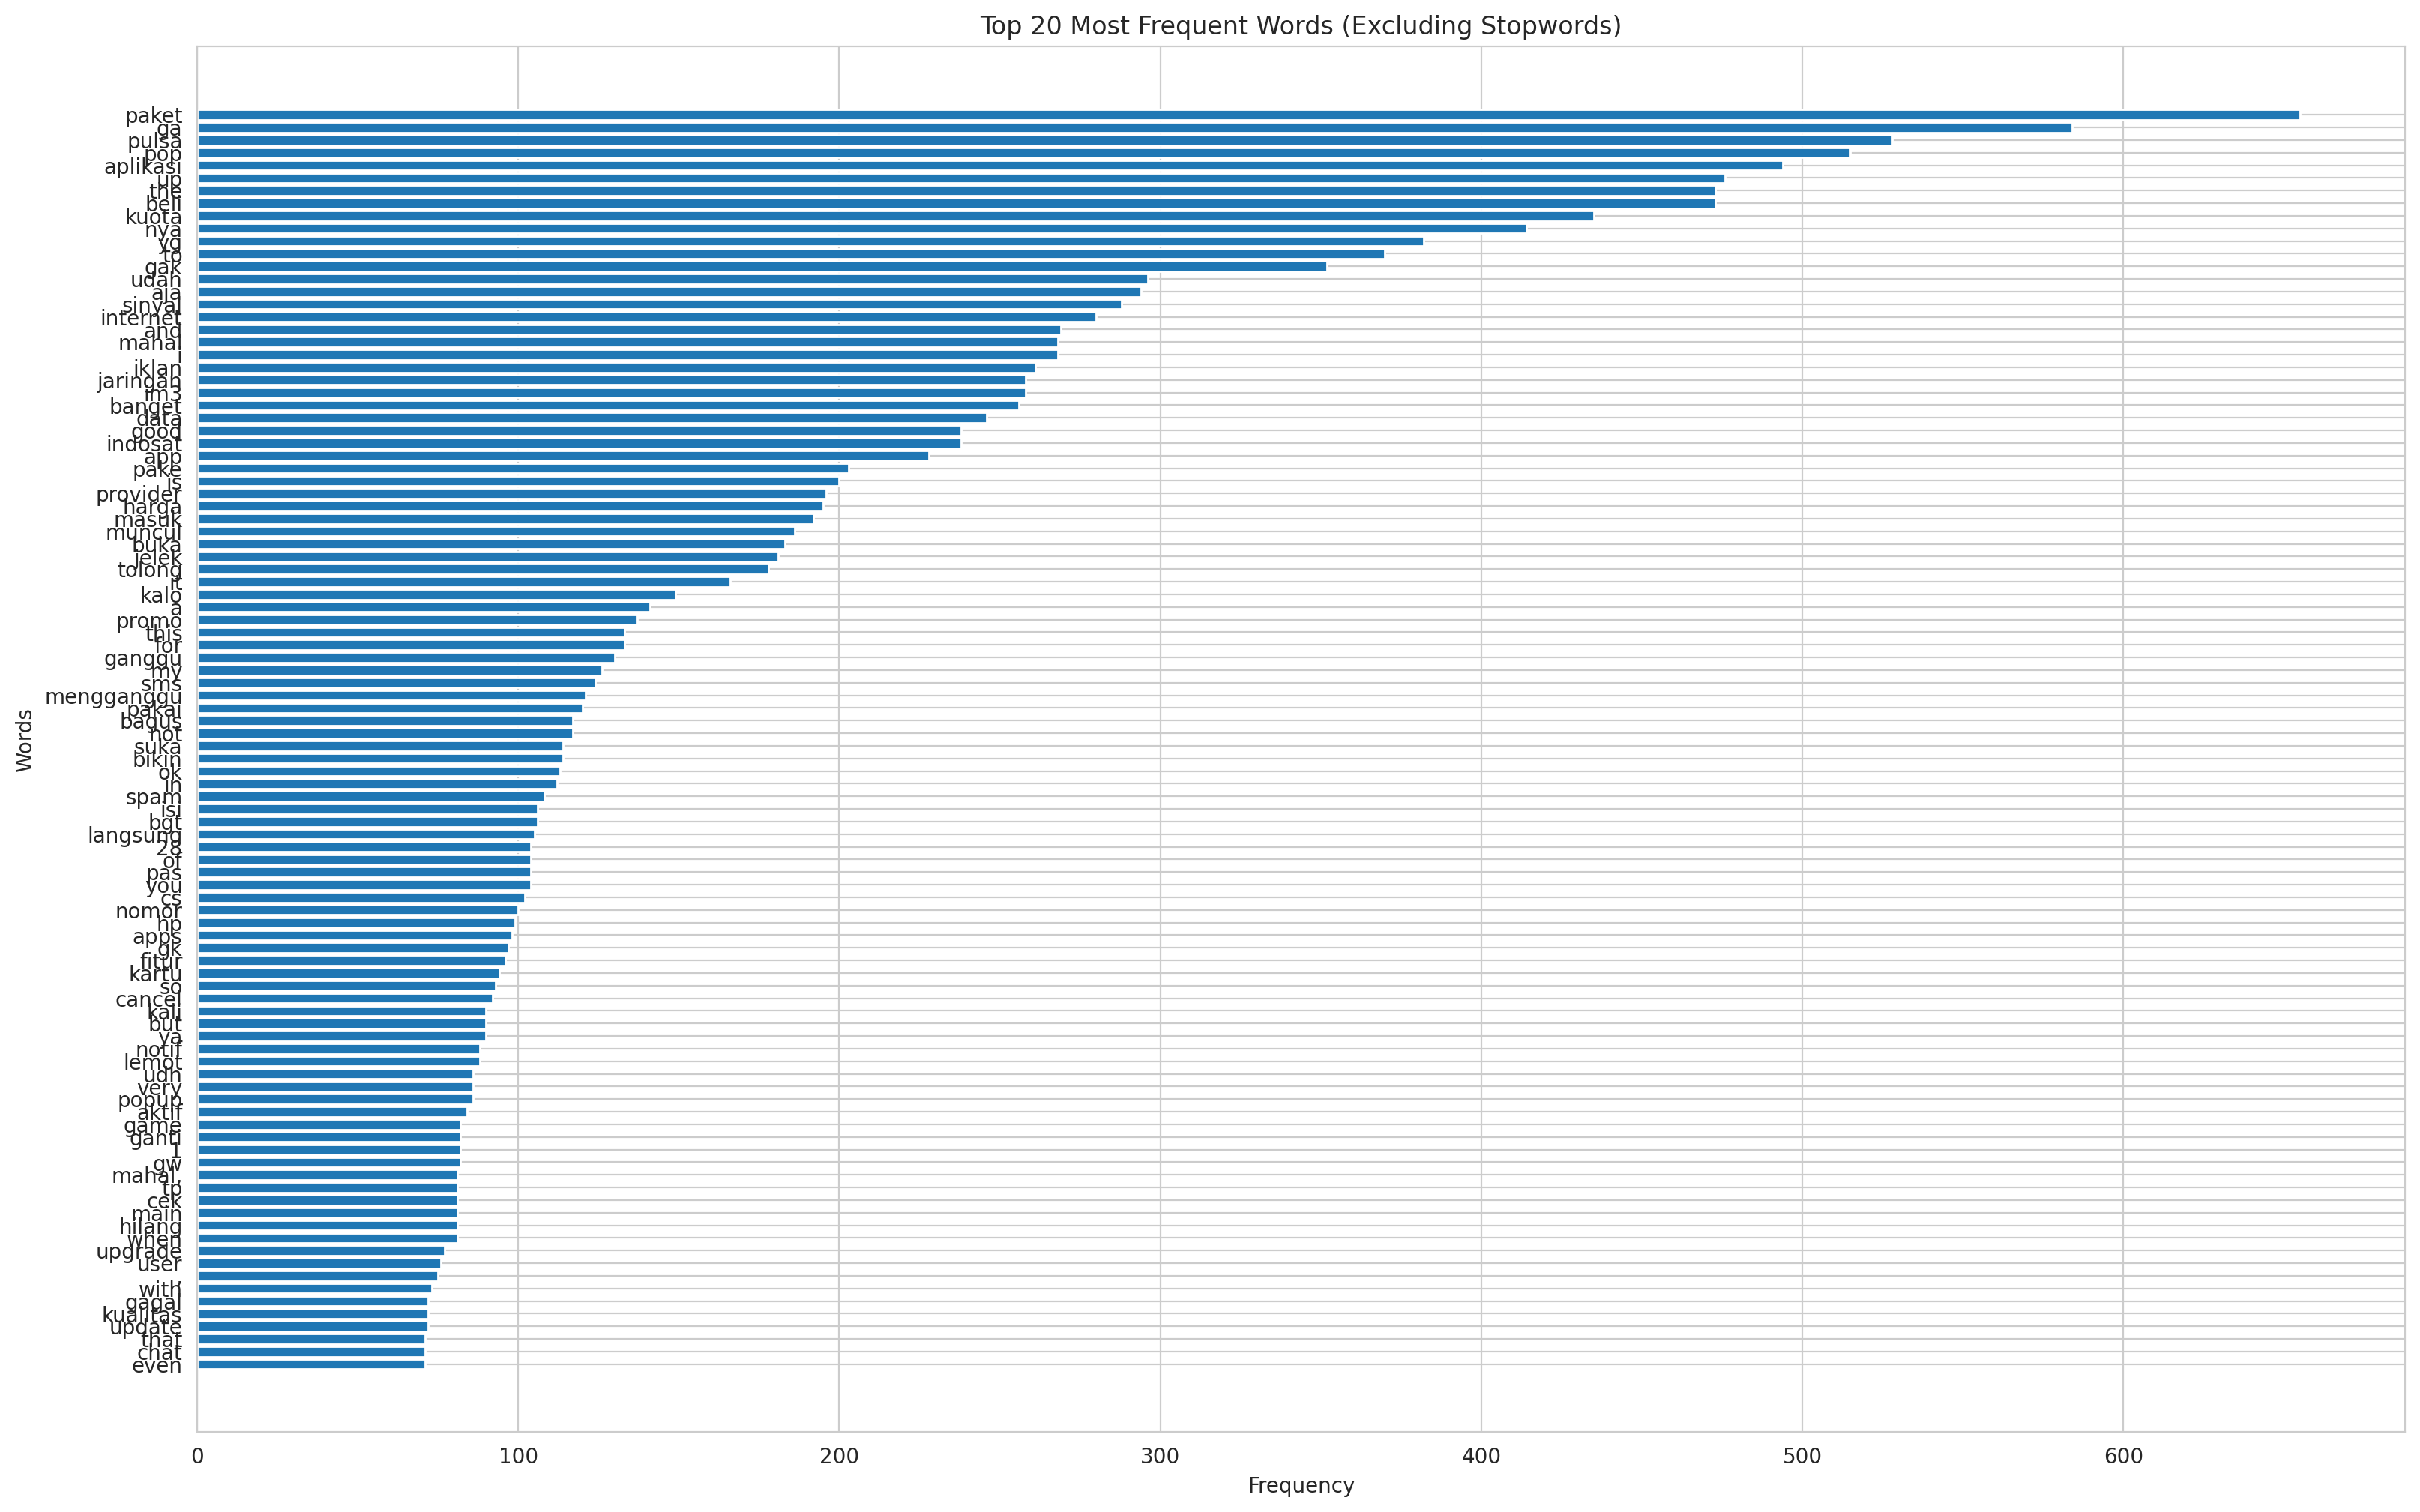

In [22]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_myim3rev[text_column].dropna().astype(str))

# Tokenize words and remove stopwords
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in indonesian_stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words
plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (Excluding Stopwords)")
plt.show()

In [13]:
common_words

[('paket', 655),
 ('ga', 584),
 ('pulsa', 528),
 ('pop', 515),
 ('aplikasi', 494),
 ('up', 476),
 ('the', 473),
 ('beli', 473),
 ('kuota', 435),
 ('nya', 414),
 ('yg', 382),
 ('to', 370),
 ('gak', 352),
 ('udah', 296),
 ('aja', 294),
 ('sinyal', 288),
 ('internet', 280),
 ('and', 269),
 ('mahal', 268),
 ('i', 268),
 ('iklan', 261),
 ('jaringan', 258),
 ('im3', 258),
 ('banget', 256),
 ('data', 246),
 ('good', 238),
 ('indosat', 238),
 ('app', 228),
 ('pake', 203),
 ('is', 200),
 ('provider', 196),
 ('harga', 195),
 ('masuk', 192),
 ('muncul', 186),
 ('buka', 183),
 ('jelek', 181),
 ('tolong', 178),
 ('it', 166),
 ('kalo', 149),
 ('a', 141),
 ('promo', 137),
 ('this', 133),
 ('for', 133),
 ('ganggu', 130),
 ('my', 126),
 ('sms', 124),
 ('mengganggu', 121),
 ('pakai', 120),
 ('bagus', 117),
 ('not', 117),
 ('suka', 114),
 ('bikin', 114),
 ('ok', 113),
 ('in', 112),
 ('spam', 108),
 ('isi', 106),
 ('bgt', 106),
 ('langsung', 105),
 ('28', 104),
 ('of', 104),
 ('pas', 104),
 ('you', 104),


Homework: WEEK 3/ 11 maret 2026 (TUGAS 2)

Bisa menambahkan, list kata dari most frequent words, kata2 yg tidak memiliki arti penting (eg ga (no-2), gak-no4) ke list indonesian_stopwords
homework ini ada di week 3 file
